In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np

from bio_optics.helper import resampling


# Application Test
The already trained inversion models based on band ratios (hyperspectral at optimal wavelength positions) are applied to the simulated spectra.
Insitu group information is used to validate the results.


## Read test data

In [30]:
metaDict = {'muggelsee': { 'project': 'HEATWISE',
        'path' : "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\",
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\\",
        'datasetNameIOP': "berlin_muggelsee_IOP_daily_v0.3.", #"berlin_muggelsee_IOP_daily_v0.3_SZA_Gx_OZA2"
        'lat': 52.4373,
        'lon': 13.6474,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold',
        'versionNumber': 'v2.0'  # something is wrong with version v0.3.0!
        }}

In [31]:
## BC Bi&Hieronymi forward simulations
## these can have CHIME wavelengths!!
regionName = 'muggelsee'
projectName =metaDict[regionName]['project']

if projectName == 'HEATWISE':
    fwpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
elif projectName == 'AQUATIME':
    fwpath ="Z:\projects\\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward\\"
iop_path = metaDict[regionName]['iop_path']

fnames = os.listdir(fwpath)
# fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName.split('_')[0] in fn and regionName.split('_')[1] in fn]
fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName in fn and 'CHIME' in fn] # CHIME bands!
print(fnames)
# # fname = "SimRrs_InsituForward_HEREONorig_HEREONgoldinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_pyhajarvi_allOWTs_Inv0_Inv0.1.txt" # naming ??
forward = pd.read_csv(fwpath+fnames[0], sep='\t', header=0)

# iop_path = 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\'
datasetNameIOP = metaDict[regionName]['datasetNameIOP']
fname = os.listdir(iop_path)
fname = [fn for fn in fname if fn.startswith(datasetNameIOP) and 'v0.3' in fn]  # Helsinki: 'IOP' in fn and ... 'v0.1b'
print(fname[0])
iop_insitu = pd.read_csv(iop_path+ fname[0], sep=',')
iop_insitu['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
iop_insitu = iop_insitu.set_index('date')

forward['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
forward = forward.set_index('date')
wl_fw = np.asarray([float(a) for a in forward.columns.values])

print('forward', forward.shape)
print('insitu', iop_insitu.shape)

['SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_CHIMEbands.txt']
berlin_muggelsee_IOP_daily_v0.3.csv
forward (3074, 71)
insitu (3074, 35)


## Setup input to trained models
XGBoost models were trained on band ratios from 1nm-resolution spectra.

CHIME data needs interpolation to the required wavelengths.

### Select best parameter set

In [253]:
PhytoType = '0'
errorpath= "D:\Documents\projects\EnsAD\XGB_Training\\xgboost_CombSimul_TuningC_20250610_v03\\figures\\"
fnames = os.listdir(errorpath)
fnames = [fn for fn in fnames if 'errors_featureReduction' in fn]
# fnames
errorDF = pd.read_csv(errorpath + "errors_featureReduction_InversionXGB_Sim2Conc_LakesC"+PhytoType+".txt", sep='\t', header=0)
# errorDF = pd.read_csv(errorpath + "errors_featureReduction_InversionXGB_Sim2Conc_SummerLakesC"+PhytoType+".txt", sep='\t', header=0)


[2.92361805 2.79488969 2.73162693 2.62445267 2.72523862 2.90040637
 2.56038807 2.78415748]
[94. 50. 40. 30. 25. 20. 15. 10.]
[50. 25. 30. 20. 94. 15. 40. 10.]


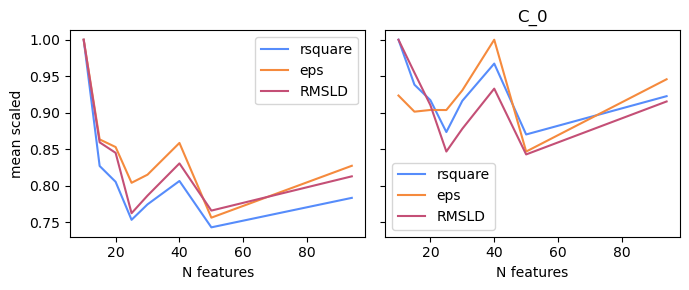

In [254]:
## mean errors over all output variables
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7,3), sharey=True)

def plot_mean_error(errorDF, ax, title=None, ylabel=None, outputBest=False):
    if outputBest:
        bestTest = np.zeros(errorDF.shape[0])
    for col in errorDF.columns.values[:-1]:
        b = errorDF.groupby('Nfeatures')[col].mean()
        if col == 'rsquare':
            ax.plot((1.-b) / np.max(1-b), label=col)
            # ax.plot((1.-b) , label=col)
            if outputBest:
                bestTest +=  (1.-b) / np.max(1-b)
                # bestTest +=  (1.-b)
        elif col == 'bias' or col == 'beta':
            ax.plot(np.abs(b) / np.max(np.abs(b)), label=col)
            if outputBest:
                bestTest +=  np.abs(b) / np.max(np.abs(b))
        else:
            ax.plot(b/np.max(b), label=col)
            if outputBest:
                bestTest +=  b / np.max(b)
    ax.legend()
    if not title is None:
       ax.set_title(title)
    ax.set_xlabel('N features')
    if not ylabel is None:
        ax.set_ylabel(ylabel)

    if outputBest:
        print(bestTest.values)
        print(errorDF['Nfeatures'].values)
        print(errorDF['Nfeatures'].values[np.argsort(bestTest[::-1])])

plot_mean_error(errorDF[['rsquare', 'eps', 'RMSLD','Nfeatures']], ax[0], ylabel='mean scaled')
x = np.unique(errorDF.Nfeatures.values)
plot_mean_error(errorDF[['rsquare', 'eps', 'RMSLD', 'Nfeatures']].iloc[:len(x)], ax[1], title='C_'+PhytoType, outputBest=True)

fig.tight_layout()

### Setup input parameter list
Find all necessary inputs or derive them

In [255]:
## minimum in scaled error values (if not total number of
bestSolutionDict = {
    'C0' : 25 , 'C1': 40, 'C2': 25, 'C3': 30, 'C4': 20, 'C5': 25, 'C6': 25,
    'C7': 40, #10, THIS MODEL is not working!
    'C5S': 25, # 15: very bad chl_tot estimation,
    'C7S': 20
}
featureList = os.listdir(errorpath)
featureList = [fn for fn in featureList if fn.startswith('feature') and fn.endswith('.txt')]

inputDict = {}
for key in bestSolutionDict.keys():
    fnf = [fn for fn in featureList if key in fn]
    if key.endswith('S'):
        fnf = [fn for fn in featureList if key[:-1] in fn]
        fnf = [fn for fn in fnf if 'Summer' in fn]

    with open(errorpath+fnf[0]) as f:
        lines = f.readlines()
        for i, l in enumerate(lines):
            if l.startswith(str(bestSolutionDict[key])):
                param = l.split(', ')
                param = param[2:]
                param[-1] = param[-1][:-1]
                print(key, param)
                inputDict[key] = param
                break

    f.close()

C0 ['604/651', '651/718', '466/425', '425/450', '674/604', '496/566', 'NDI', '604', '438/496', '496/604', '636/604', '636/651', '413', '413/674', '566/604', '438/450', '413/566', '674', '674/718', '466/450', '466/496', '413/425', '496/480', '466/480', '438/425']
C1 ['650', '550/658', '414/650', '550/638', '438/675', 'scaledAVW', '718', '638', '650/675', '675/638', '460/550', '478/718', '658', '438/638', 'log10Area', '675/658', '675/550', '438', '478/658', '414', '414/550', '414/478', '675/460', '550', '638/658', '650/550', '414/460', 'NDI', '438/718', '650/718', '478/675', '650/658', '478/460', '438/460', '478/550', '675', '658/718', '675/718', '414/438', '650/638']
C2 ['453/482', '414/453', '522/604', '426/482', '437/468', '453/522', '604/650', '468/522', '676/718', '414/548', '632/604', '414/426', '548/604', '414/522', '437/453', '437/497', '676', '548/522', '414/676', '437/426', '497/453', '497/522', '468/453', '497/482', '468/482']
C3 ['log10Area', 'NDI', '436/677', '416/454', '416

In [94]:
### Descriptive Wavelengths of all Phytoplankton Groups (combined wavelengths for HEREON, LOMAS, Summer)
wavelengthDict = {
    'C0' : { # Brown
        'max': [413., 438., 466., 496., 636., 674.],
        'min': [425., 450., 480., 566., 604., 651., 718.], # 718 added for TSM (718 is still in PACE)
    },
    'C1' : { # Green
        'max': [414., 438., 478., 650., 675.],
        'min': [460., 550., 638., 658., 718.],  # 718 added for TSM
        },
    'C2' : { # Crypto
        'max': [414., 437., 468., 497., 548., 632., 676.],
        'min': [426., 453., 482., 522., 604. ,650., 718.],},
    'C3' : { # Cyano blue
        'max': [416., 436., 496., 627., 677.],
        'min': [454., 478., 550., 602., 654, 718.]},
    'C4' : { # Cyano red
        'max': [414., 437., 497., 542., 565., 630., 677.],
        'min': [426., 456., 478., 522., 600., 610., 650., 718.]},
    'C5' : { # Coccolith.
        'max': [414., 440., 464., 494., 591., 637., 676.],
        'min': [426., 452.,  570., 606., 620., 652., 660., 718.]},
    'C6' : { # Dinoflagellate
        'max': [412., 438., 468., 496., 538., 570., 592., 620., 633., 676.],
        'min': [424., 436., 450., 484., 512., 569., 604., 652., 718.]},
    'C7' : { # case-1
        'max': [419., 442., 490., 628., 673.],
        'min': [444., 510., 528., 568., 652., 718.]},
    'C5S' : { # Phaeocystis
        'max': [414., 440., 470., 538., 591., 638., 675.],
        'min': [426., 452., 514., 570., 606., 652., 718.]},
    'C7S' : { # Noctiluca
        'max': [410., 464., 485., 520., 626., 672.],
        'min': [444., 510., 528., 568., 652., 718.]},
}

In [131]:
def setup_InputXGBmodel_ordered(inputDict, wavelengthDict):
    outDict = {}
    for PhytoType in inputDict.keys():
        ## all Permutations of band ratios
        input_names_WL = [str(int(a)) for a in wavelengthDict[PhytoType]['max']]
        [input_names_WL.append(str(int(b))) for b in wavelengthDict[PhytoType]['min']]
        BandRatioList = []
        for i, wl1 in enumerate(input_names_WL):
            for j, wl2 in enumerate(input_names_WL[i:]):
                if j > 0:
                    BandRatioList.append(str(int(wl1)) + '/' + str(int(wl2)))

        wavelengthDict[PhytoType]['rel'] = BandRatioList

        ## NN Inverse model: 'input_names', 'input_names_WL', 'input_names_BR'  -> 'C_X', 'C_phy', 'C_Y', 'C_ism'
        # input_names_WL = [str(int(a)) for a in wavelengthDict[PhytoType]['max']]
        # [input_names_WL.append(str(int(b))) for b in wavelengthDict[PhytoType]['min']]

        NNtraining_metadata = {
            'output_label': ['C_' + PhytoType, 'C_phy', 'C_Y', 'C_ism'],  # 'C_0', 'C_1','C_2','C_3','C_4', 'C_6'
            'input_names': ['scaledAVW', 'log10Area', 'NDI'],
            'input_names_WL': input_names_WL,
            'input_names_BR': wavelengthDict[PhytoType]['rel'],
            # 'transformation_method': '',  # 'log', 'sqrt'
            # 'outpath': "D:\Documents\projects\EnsAD\XGB_Training\\xgboost_CombSimul_TuningC_20250613_v03\\",
            # 'maxEpochs': 40000,  # 30, bei block_size=1; 15000 bei block_size=1000
        }

        revisedOrderInput = NNtraining_metadata['input_names'].copy()
        [revisedOrderInput.append(a) for a in NNtraining_metadata['input_names_WL']]
        [revisedOrderInput.append(b) for b in NNtraining_metadata['input_names_BR']]
        revisedOrderInput = [a for a in revisedOrderInput if a in inputDict[PhytoType]]
        OrderType = []
        [OrderType.append('P') for a in revisedOrderInput if a in NNtraining_metadata['input_names']]
        [OrderType.append('WL') for a in revisedOrderInput if a in NNtraining_metadata['input_names_WL']]
        [OrderType.append('BR') for a in revisedOrderInput if a in NNtraining_metadata['input_names_BR']]

        outDict[PhytoType] = {}
        outDict[PhytoType]['cols'] = np.asarray(revisedOrderInput)
        outDict[PhytoType]['type'] = np.asarray(OrderType)

    return outDict


In [256]:
inputDictOrdered = setup_InputXGBmodel_ordered(inputDict, wavelengthDict)

In [133]:
def calculate_AVW_NDI_Area(r_rs, wlstr, orig):
    # Calculate OWT measurement values: AVW, Area, NDI
    ## AVW
    RrsArrayWL = r_rs.copy()
    for i in range(RrsArrayWL.shape[1]):
        RrsArrayWL[:, i] = r_rs[:, i] / float(wlstr[i])

    AVW = np.sum(r_rs, axis=1) / np.sum(RrsArrayWL, axis=1)
    print(AVW.shape)

    ## Area
    sensor_RGB_bands = ['442', '560', '665'] # closest bands to 443, 560, 665nm
    bands_for_Area = np.asarray([float(a) for a in sensor_RGB_bands])

    Rrs_for_Area = orig[sensor_RGB_bands].values
    Area = np.trapezoid(y=Rrs_for_Area, x=bands_for_Area)
    print(Area.shape)

    ## NDI
    Rrs_for_NDI = orig[sensor_RGB_bands[1:]].values
    diff = -np.diff(Rrs_for_NDI, axis=1)[:, 0]
    sum_ = np.sum(Rrs_for_NDI, axis=1)
    NDI = diff / sum_
    print(NDI.shape)
    return AVW, NDI, Area

In [138]:
def setup_training_data_selection_generic(inputDict= None, outputDict=None,
                                          ID=None  # selection
                                          ):
    this_input = None
    this_output = None

    if not inputDict is None:
        for key in inputDict.keys():
            input_col = inputDict[key]['col']
            if not ID is None:
                this_input_ = inputDict[key]['data'][input_col].loc[ID, :]
                this_input_ = this_input_.reset_index(drop=True)
            else:
                this_input_ = inputDict[key]['data'][input_col]

            logTrans_col = inputDict[key]['logTrans_col']
            threshold = inputDict[key]['threshold']
            if not logTrans_col is None:
                for col, thres in zip(logTrans_col, threshold):
                    if not thres is None:
                        ID_ = np.array(this_input_[col].values < thres)
                        if np.sum(ID_) > 0:
                            this_input_.loc[ID_, col] = thres
                    this_input_.loc[:, col] = np.log10(this_input_[col].values)

            if this_input is None:
                this_input = this_input_
            else:
                this_input = pd.concat([this_input, this_input_], axis=1)

    if not outputDict is None:
        for key in outputDict.keys():
            output_col = outputDict[key]['col']
            if not ID is None:
                this_output_ = outputDict[key]['data'][output_col].loc[ID, :]
                this_output_ = this_output_.reset_index(drop=True)
            else:
                this_output_ = outputDict[key]['data'][output_col]

            logTrans_col = outputDict[key]['logTrans_col']
            threshold = outputDict[key]['threshold']
            if not logTrans_col is None:
                for j, col in enumerate(logTrans_col):
                    if not threshold is None:
                        thres = threshold[j]
                        ID_ = np.array(this_output_[col].values < thres)
                        if np.sum(ID_) > 0:
                            this_output_.loc[ID_, col] = thres
                    this_output_.loc[:, col] = np.log10(this_output_[col].values)

            if this_output is None:
                this_output = this_output_
            else:
                this_output = pd.concat([this_output, this_output_], axis=1)

    return this_input, this_output

In [203]:
## interpolate spectrum to 1nm within range 400-750 (splines?)
from scipy.interpolate import interp1d
wl_target = np.arange(400., 751., 1.)
Rrs1nm = np.zeros((forward.shape[0], len(wl_target)))
for i in range(Rrs1nm.shape[0]):
    interp = interp1d(wl_fw, forward.iloc[i,:], fill_value='extrapolate')
    Rrs1nm[i,:] = interp(wl_target)

Rrs1nmDF = pd.DataFrame(Rrs1nm, columns=[str(int(wl)) for wl in wl_target])

# Calculate NDI, AVW, Area -> transform to scaledAVW, log10Area
AVW, NDI, Area = calculate_AVW_NDI_Area(Rrs1nmDF.values, Rrs1nmDF.columns.values, Rrs1nmDF)
X_test = pd.DataFrame()
X_test['scaledAVW'] = (AVW - 400.) / (720. - 400.)
X_test['log10Area'] = np.log10(Area)
X_test['NDI'] = NDI

(3074,)
(3074,)
(3074,)


In [257]:
PhytoType='0'

## BandRatio DF
# ## Simulations Rrs Bandratios
input_BandRatio = pd.DataFrame()
print(inputDictOrdered['C'+PhytoType]['type'])
IDbandratio = inputDictOrdered['C'+PhytoType]['cols'][inputDictOrdered['C'+PhytoType]['type']=='BR']
for br in IDbandratio:
    b1, b2 = br.split('/')
    input_BandRatio[br] = Rrs1nmDF[b1].values / Rrs1nmDF[b2].values


inputDict_Model = {
    'parameter': {'data': X_test,
             'col': inputDictOrdered['C'+PhytoType]['cols'][inputDictOrdered['C'+PhytoType]['type']=='P'],
             'threshold': None,
             'logTrans_col': None},
    'bands': {'data': Rrs1nmDF,
             'col': inputDictOrdered['C'+PhytoType]['cols'][inputDictOrdered['C'+PhytoType]['type']=='WL'],
             'threshold': None,
             'logTrans_col': None},
    'BandRatio': {'data': input_BandRatio,
                 'col': input_BandRatio.columns.values,
                 'threshold': None,
                 'logTrans_col': None}
}

thisInput, thisOutput =  setup_training_data_selection_generic(inputDict= inputDict_Model, outputDict=None, ID=None)


['P' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


In [226]:
thisInput

,414,675,414/440,414/426,414/514,440/591,440/426,440/452,470/426,470/452,...,591/426,591/514,591/570,591/606,638/606,638/652,675/718,452/514,570/606,652/718
0,0.001597,0.001731,0.691102,0.841368,0.287183,0.482063,1.217430,0.843532,1.854222,1.284751,...,2.525459,0.862010,0.677020,1.605483,0.864111,1.153507,2.570919,0.492623,2.371398,3.321404
1,0.001576,0.001689,0.691229,0.841432,0.288202,0.486437,1.217299,0.843803,1.853559,1.284843,...,2.502483,0.857134,0.675509,1.608378,0.863663,1.153471,2.576308,0.494122,2.380986,3.328944
2,0.001556,0.001648,0.691496,0.841578,0.289265,0.490730,1.217039,0.844102,1.852422,1.284784,...,2.480059,0.852439,0.674038,1.611094,0.863181,1.153480,2.580595,0.495577,2.390213,3.335348
3,0.001536,0.001608,0.691886,0.841795,0.290362,0.494921,1.216667,0.844425,1.850872,1.284594,...,2.458307,0.847949,0.672612,1.613629,0.862677,1.153525,2.583908,0.496986,2.399050,3.340735
4,0.001516,0.001569,0.692378,0.842070,0.291480,0.498985,1.216200,0.844767,1.848978,1.284292,...,2.437349,0.843681,0.671236,1.615985,0.862159,1.153597,2.586379,0.498343,2.407478,3.345224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3069,0.001297,0.001571,0.694484,0.843632,0.283138,0.435971,1.214760,0.843408,1.852106,1.285917,...,2.786331,0.935143,0.716863,1.568914,0.865657,1.150774,2.521277,0.483391,2.188585,3.295493
3070,0.001317,0.001608,0.694321,0.843522,0.282753,0.433546,1.214887,0.843284,1.852498,1.285866,...,2.802209,0.939316,0.719003,1.566007,0.866079,1.150608,2.517792,0.482918,2.178024,3.291353
3071,0.001334,0.001641,0.694277,0.843483,0.282476,0.431428,1.214908,0.843200,1.852517,1.285729,...,2.816018,0.943061,0.720967,1.563322,0.866420,1.150476,2.514050,0.482522,2.168368,3.287101
3072,0.001350,0.001671,0.694319,0.843496,0.282269,0.429505,1.214853,0.843143,1.852268,1.285527,...,2.828493,0.946531,0.722814,1.560777,0.866705,1.150371,2.510058,0.482172,2.159307,3.282688


## Apply trained models to input

In [258]:
xgb_model_path = "D:\Documents\projects\EnsAD\XGB_Training\\xgboost_CombSimul_TuningC_20250610_v03\\invNNoneC_specifWL\\"

## select the correct model based on the number of inputs and the phytoplankton group
modelFnames = os.listdir(xgb_model_path)
# ../model_InversionXGB_Sim2Conc_I10_O4log_LakesC1
if PhytoType.endswith('S'):
    modelFnames = [mf for mf in modelFnames if 'I'+str(bestSolutionDict['C'+PhytoType]) in mf and 'SummerLakesC'+PhytoType[:-1] in mf]
else:
    modelFnames = [mf for mf in modelFnames if 'I'+str(bestSolutionDict['C'+PhytoType]) in mf and 'LakesC'+PhytoType in mf]
modelFnames

['model_InversionXGB_Sim2Conc_I25_O4log_LakesC0.json']

In [259]:
import xgboost as xgb
n = 2000

model_inv = xgb.XGBRegressor(objective="reg:squarederror", eval_metric=['rmse'], early_stopping_rounds=3,
                             n_estimators=n, learning_rate=0.2)  # n=20000

model_inv.load_model(xgb_model_path+modelFnames[0])
CX_predict = model_inv.predict(thisInput.values)

In [153]:
iop_insitu.columns.values

<ArrowStringArray>
[               'datetime',                 'Temp °C',
          'Salinity [PSU]',             'Chlg [µg/l]',
              'Cgr [µg/l]',             'Ckie [µg/l]',
              'Cbl [µg/l]',             'Cbl2 [µg/l]',
             'Ccry [µg/l]',            'Cgold [µg/l]',
            'Cdino [µg/l]',           'ag(440) [1/m]',
               'Sg [1/nm]',             'TSPM [mg/l]',
              'NAP [mg/l]', 'anap_spec(440) [m2 g-1]',
             'Snap [1/nm]',        'latitude_station',
       'longitude_station',           'latitude_cams',
          'longitude_cams',                     'u10',
                     'v10',                'bcaod550',
                'duaod550',                'omaod550',
                'ssaod550',                  'aod469',
                  'aod550',                  'aod670',
                  'aod865',                 'aod1240',
                  'tc_ch4',                   'gtco3',
                    'tcwv']
Length: 35, dtype:

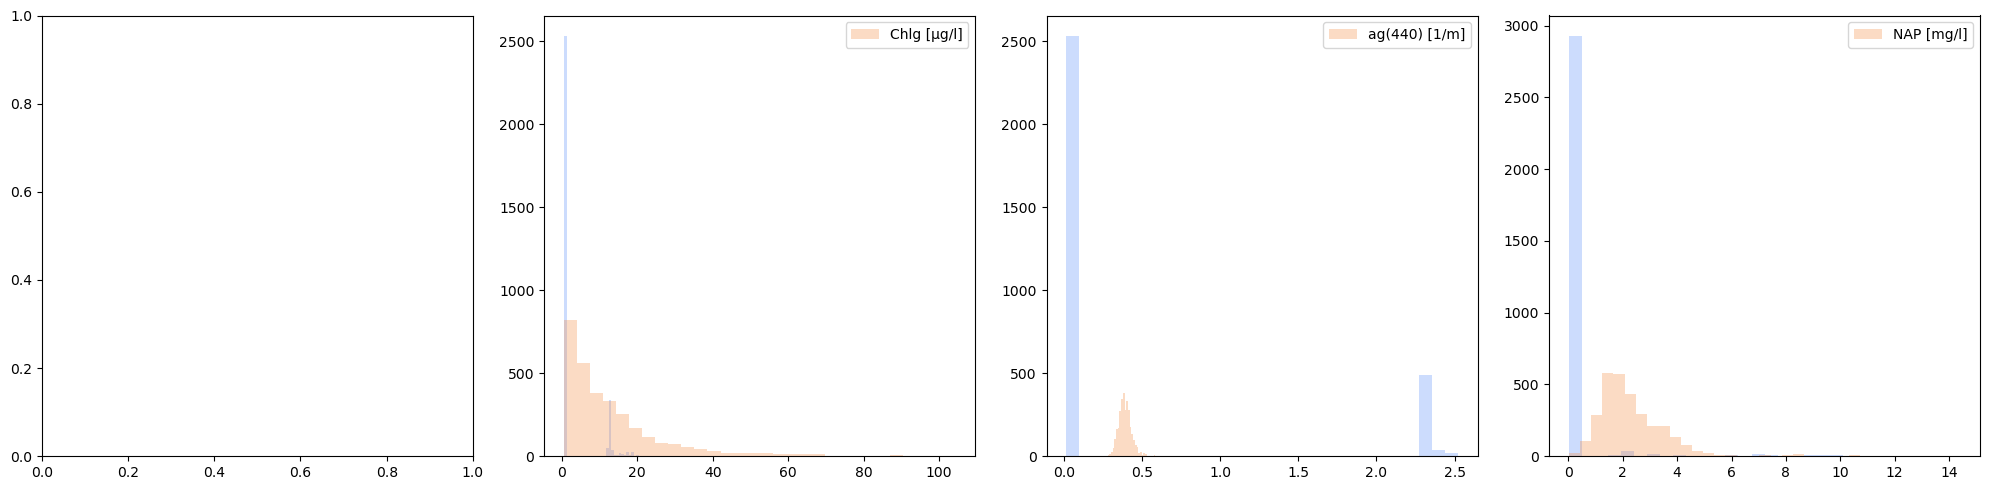

In [239]:
insituDict = { 'C0': ['Ckie [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C1': ['Cgr [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C2': ['Ccry [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C3': ['Cbl [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C4': ['Cbl2 [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C5': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # coccoliths: not available in insitu!
               'C6': ['Cdino [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
               'C7': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # case-1
               'C5S': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # Phaeocystis
               'C7S': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # Noctiluca
               }
insituVarL = insituDict['C'+PhytoType]
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))
for i in range(4):
    if not insituVarL[i] is None:
        ax[i].hist(10**CX_predict[:,i], 30, alpha=0.3)
        ax[i].hist(iop_insitu[insituVarL[i]], 30, alpha=0.3, label=insituVarL[i])
        ax[i].legend()
fig.tight_layout()
plt.show()

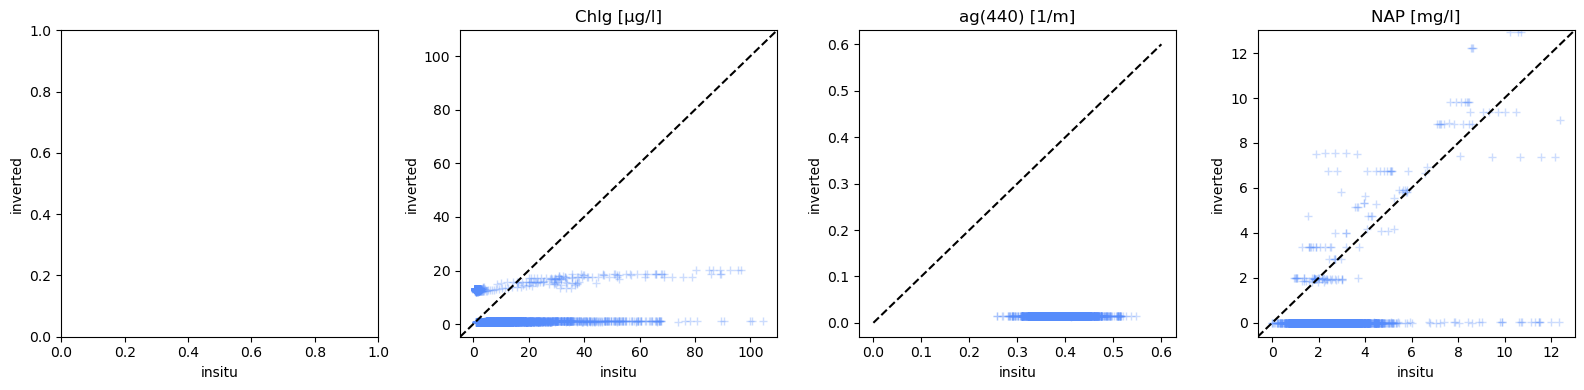

In [240]:
# insituVarL = ['Ckie [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]']
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))
for i in range(4):
    if not insituVarL[i] is None:
        ax[i].plot(iop_insitu[insituVarL[i]], 10**CX_predict[:,i], '+', alpha=0.3)
        ax[i].set_title(insituVarL[i])

        xlim = ax[i].get_xlim()
        if xlim[0]<0:
            ax[i].plot(xlim, xlim, 'k--')
            ax[i].set_xlim(xlim)
            ax[i].set_ylim(xlim)
        elif xlim[0]>0:
            ax[i].plot((0,xlim[1]), (0,xlim[1]), 'k--')
            xlim = ax[i].get_xlim()
            ax[i].set_ylim(xlim)
    ax[i].set_xlabel('insitu')
    ax[i].set_ylabel('inverted')
fig.tight_layout()
plt.show()

In [297]:
## statistics functions
def logarithmic_errors(y, x):
    Q = y/x
    eps = 100.* (np.exp(np.nanmedian(np.abs(np.log(Q)))) - 1.)
    beta = 100. * np.sign(np.nanmedian(np.log(Q))) * (np.exp(np.abs(np.nanmedian(np.log(Q)))) - 1)
    RMSLD = np.nanmean((np.log10(y+1) - np.log10(x+1))**2.)
    return eps, beta, RMSLD


def plot_validation_results(y_test, results, output_label,
                            thisLim = np.array((-2.5, 2.5)),
                            logStat = [True],  # either single boolean for all output_label, or list of boolean for each output_label
                            minVDict = { },
                            maxVDict = { },
                            stat_output=False,
                            logNorm=True):  #'C_phy' :  3, 'C_Y' : 1.5, 'C_ism': 2.5
    ix = 0
    Nx = len(output_label)

    outStat = np.zeros((Nx, 5))

    fig, ax = plt.subplots(nrows=1, ncols=Nx, figsize=(15*(Nx/4.),4))
    for j, col in enumerate(output_label):
        if not col is None:
            ax[ix].plot(y_test[col], results[:, j], '+', alpha=0.2)

            ## R-square, Bias
            rsquare = np.corrcoef(y_test[col], results[:, j])
            bias = np.nanmean(results[:, j]-y_test[col])

            ## OShea Paper - logarithmic stats
            if logNorm:
                eps, beta, RMSLD = logarithmic_errors(10**results[:, j], 10**y_test[col])
            else:
                eps, beta, RMSLD = logarithmic_errors(results[:, j], y_test[col])

            if stat_output:
                outStat[j,0]= rsquare[0,1]
                outStat[j,1]= bias
                outStat[j,2]= eps
                outStat[j,3]= beta
                outStat[j,4]= RMSLD

            xlim = ax[ix].get_xlim()
            ax[ix].plot(xlim, xlim, 'k--')
            # ax[iy, ix].set_xlim(xlim)

            thisLim_ = thisLim.copy()
            if col in maxVDict.keys():
                thisLim_[1] = maxVDict[col]
            if col in minVDict.keys():
                thisLim_[0] = minVDict[col]

            ax[ix].set_xlim(thisLim_)
            ax[ix].set_ylim(thisLim_)

            if len(logStat)>1:
                if logStat[j]:
                    ax[ix].set_title(col + ' r2=' + str(np.round(rsquare[0, 1],2)) + ' bias=' +str(np.round(bias,4)) + '\n'+
                                'eps=' + str(np.round(eps,1)) + '% beta=' + str(np.round(beta,1)) + '% rsmld='+ str(np.round(RMSLD,3)))
            else:
                if logStat[0]:
                    ax[ix].set_title(col + ' r2=' + str(np.round(rsquare[0, 1],2)) + ' bias=' +str(np.round(bias,4)) + '\n'+
                                    'eps=' + str(np.round(eps,1)) + '% beta=' + str(np.round(beta,1)) + '% rsmld='+ str(np.round(RMSLD,3)))
                else:
                    ax[ix].set_title(col + ' r2=' + str(np.round(rsquare[0, 1],2)) + ' bias=' +str(np.round(bias,4)))

        ax[ix].set_xlabel('original')
        ax[ix].set_ylabel('predicted')
        ix +=1
        if ix==Nx:
            ix=0

    fig.tight_layout()
    plt.show()

    if stat_output:
        outStatDF = pd.DataFrame(outStat, columns=['r2', 'bias', 'eps', 'beta', 'RMSLD'])
        outStatDF['Var'] = output_label
        return outStatDF


In [286]:
insituLog = iop_insitu[insituVarL[1:]].copy()
for a in insituLog.columns.values:
    insituLog[a] = np.log10(insituLog[a])
statDF = plot_validation_results(insituLog, CX_predict[:,1:], output_label=insituVarL[1:],
                            thisLim = np.array((-0.5, 2.5)),
                            logStat = [True],  # either single boolean for all output_label, or list of boolean for each output_label
                            minVDict = { 'Chlg [µg/l]': -0.5, 'ag(440) [1/m]': -1., 'NAP [mg/l]': -3.0},
                            maxVDict = { 'Chlg [µg/l]': 2.2, 'ag(440) [1/m]': 0., 'NAP [mg/l]': 1.},
                                 stat_output=True)

KeyError: "None of [Index(['Chlg', 'C_Y', 'C_ism'], dtype='str')] are in the [columns]"

# Automated Inversion application - all models / Tuning
- Tuning needs to be done on the validation part of the original training data!
Error values above are based on that training data and the single phyto component C_X only. We also need to find the best model for estimating total chl, tsm and acdom, if we still want to create an optical closure approach.

- Calculate retrieval errors for all the parameters! Errors of log10 values!

- True validation against the Mueggelsee data only for the selection of the best models (for each parameter)!



### EnMAP Validation data

In [302]:
## read the validation data of the training (EnMAP only)
date = '20250516'
path = "D:\Documents\projects\EnsAD\EnMAP\L2A_Land\\v010502\EnMAP_NN_Training\\NN_EnMAP2Model\data\\"+date+"\\"
typeD = 'Validation'
dataType = "EnMAP2Model"
inputDF_val = pd.read_csv(path + "origPCAloads_"+typeD+"_EnMAP2Model_"+date+ "_Lakes.txt", header=0, sep='\t')
outputDF_val = pd.read_csv(path + "simPCAloads_"+typeD+"_EnMAP2Model_"+date+"_Lakes.txt", header=0, sep='\t')
iop_val = pd.read_csv(path + "iop_"+typeD+"_EnMAP2Model_"+date+ "_Lakes.txt", header=0, sep='\t')
sim_val = pd.read_csv(path + "sim_"+typeD+"_EnMAP2Model_"+date+ "_Lakes.txt", header=0, sep='\t')

origOWT_val = pd.read_csv(path + "orig_"+typeD+"_EnMAP2Model_"+date+ "_Lakes.txt", header=0, sep='\t', usecols = ['OWT'])

colList = [a for a in inputDF_val.columns.values if not 'Unnamed' in a]
inputDF_val = inputDF_val[colList]
colList = [a for a in outputDF_val.columns.values if not 'Unnamed' in a]
outputDF_val = outputDF_val[colList]
colList = [a for a in iop_val.columns.values if not 'Unnamed' in a]
iop_val = iop_val[colList]
colList = [a for a in sim_val.columns.values if not 'Unnamed' in a]
sim_val = sim_val[colList]

iop_val['Chlg'] = np.sum(iop_val[['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7']].values, axis=1)


In [275]:
iop_val

,C_0,C_1,C_2,C_3,C_4,C_5,C_6,C_7,C_Y,C_ism,...,g_dd,g_dsr,g_dsa,d_r,f_dd,f_ds,offset,fit_surface,C_phy,Chlg
0,0.425887,0.000000e+00,6.273500e-35,4.790320e-25,3.662653e-17,0.0,3.990154e-18,0.0,1.288350e-25,0.005812,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,0.425887,0.425887
1,0.521486,0.000000e+00,1.040021e-34,3.827196e-21,2.264183e-18,0.0,6.007149e-11,0.0,1.015176e-18,0.004322,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,0.521486,0.521486
2,0.490526,0.000000e+00,1.007425e-39,3.010296e-18,1.452411e-15,0.0,2.684957e-15,0.0,6.360456e-19,0.006271,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,0.490526,0.490526
3,0.409723,0.000000e+00,2.234194e-44,3.666836e-20,1.678219e-19,0.0,2.275977e-15,0.0,1.981488e-22,0.009359,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,0.409723,0.409723
4,0.454192,0.000000e+00,2.535587e-11,6.056879e-14,6.710153e-12,0.0,4.876110e-09,0.0,1.016520e-16,0.017644,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,0.454192,0.454192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7741,20.441377,3.032218e+01,4.317691e-01,4.175857e+01,2.186121e+00,0.0,3.658108e+01,0.0,1.213388e+01,2.288685,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,131.721098,131.721098
7742,46.148357,3.030364e+01,5.630543e+00,3.276900e+01,9.542097e+00,0.0,4.526973e-24,0.0,1.260510e+01,3.750102,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,124.393641,124.393641
7743,10.312677,5.851967e+00,2.289928e-07,1.277743e+01,9.752950e-08,0.0,1.786447e-06,0.0,9.552638e+00,0.759509,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,28.942074,28.942074
7744,45.350093,3.637440e-21,1.319358e-34,5.242819e+01,2.176442e+00,0.0,8.811009e-17,0.0,1.807101e+01,6.906724,...,-inf,-inf,-inf,-inf,-inf,-inf,0.0,0.0,99.954726,99.954726


### PACE Validation data

In [292]:
date = '20250512'
IOPset = 'HEREON'
path = "E:\Documents\projects\EnsAD\\NN_training\\NN_PACE2Model\data\\"+date+"\\"
typeD = 'Validation'
inputDF_val = pd.read_csv(path + "origPCAloads_"+typeD+"_PACE2Model_"+date+ '_'+IOPset+".txt", header=0, sep='\t')
outputDF_val = pd.read_csv(path + "simPCAloads_"+typeD+"_PACE2Model_"+date+'_'+IOPset+".txt", header=0, sep='\t')
orig_val = pd.read_csv(path + "orig_"+typeD+"_PACE2Model_"+date+ '_'+IOPset+".txt", header=0, sep='\t')
sim_val = pd.read_csv(path + "sim_"+typeD+"_PACE2Model_"+date+ "_" + IOPset+ ".txt", header=0, sep='\t')
iop_val = pd.read_csv(path + "iop_"+typeD+"_PACE2Model_"+date+ "_" + IOPset+ ".txt", header=0, sep='\t')

origOWT_val = pd.read_csv(path + "orig_"+typeD+"_PACE2Model_"+date+ '_'+IOPset+".txt", header=0, sep='\t', usecols = ['OWT'])

colList = [a for a in inputDF_val.columns.values if not 'Unnamed' in a]
inputDF_val = inputDF_val[colList]
colList = [a for a in outputDF_val.columns.values if not 'Unnamed' in a]
outputDF_val = outputDF_val[colList]
colList = [a for a in orig_val.columns.values if not 'Unnamed' in a]
orig_val = orig_val[colList]
colList = [a for a in sim_val.columns.values if not 'Unnamed' in a]
sim_val = sim_val[colList]
colList = [a for a in iop_val.columns.values if not 'Unnamed' in a]
iop_val = iop_val[colList]

iop_val['Chlg'] = np.sum(iop_val[['C_0', 'C_1', 'C_2', 'C_3', 'C_4', 'C_5', 'C_6', 'C_7']].values, axis=1)


## Convert to CHIME like data
- Convolve CHIME bands from perfect simulation spectra
- Interpolate the spectra back to 1nm resolution
- apply all models

## Apply all models

In [279]:
def set_inputDict_byPhytoGroup(phytoGroup):
    inputDict = {}

    fnf = [fn for fn in featureList if phytoGroup in fn]
    if phytoGroup.endswith('S'):
        fnf = [fn for fn in featureList if phytoGroup[:-1] in fn]
        fnf = [fn for fn in fnf if 'Summer' in fn]

    d = pd.read_csv(errorpath+fnf[0])
    modelNparamList = np.asarray(np.unique(d.iloc[:,0].values), dtype=int)

    for mN in modelNparamList:

        with open(errorpath+fnf[0]) as f:
            lines = f.readlines()
            for i, l in enumerate(lines):
                if l.startswith(str(mN)):
                    param = l.split(', ')
                    param = param[2:]
                    param[-1] = param[-1][:-1]
                    # print(mN, param)
                    inputDict[str(mN)] = param
                    break
        f.close()

    return inputDict

C5 10
['WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


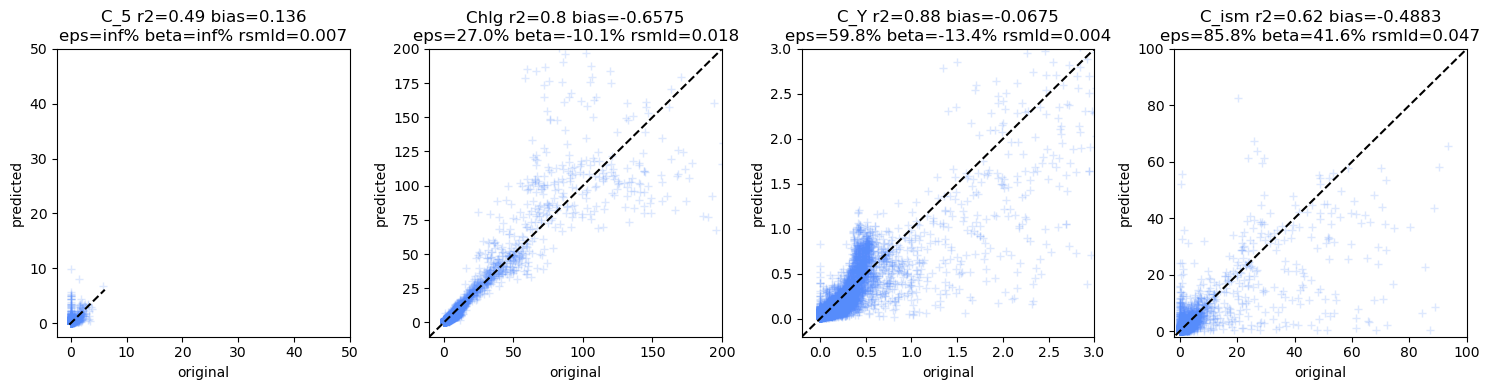

C5 15
['WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR']


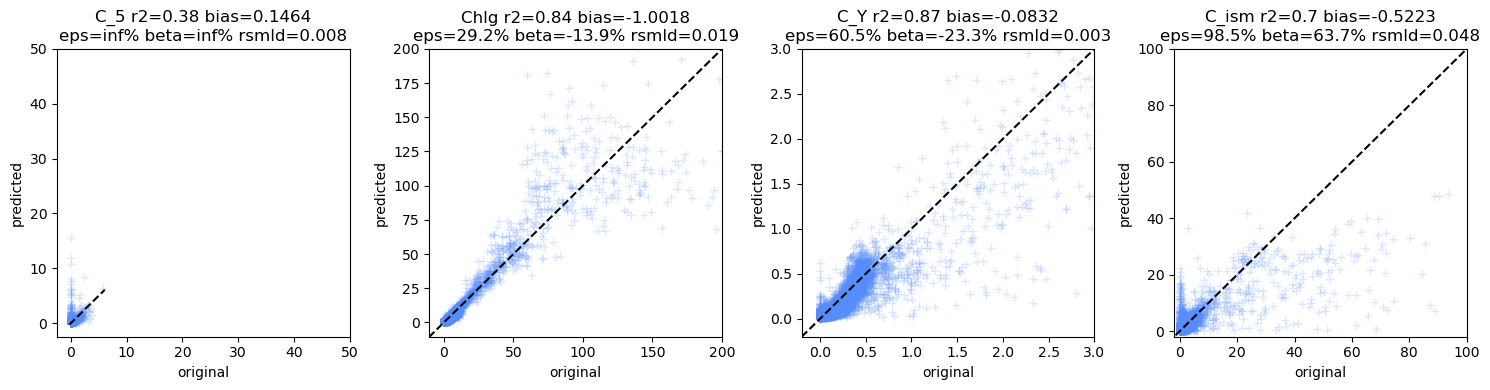

C5 20
['WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


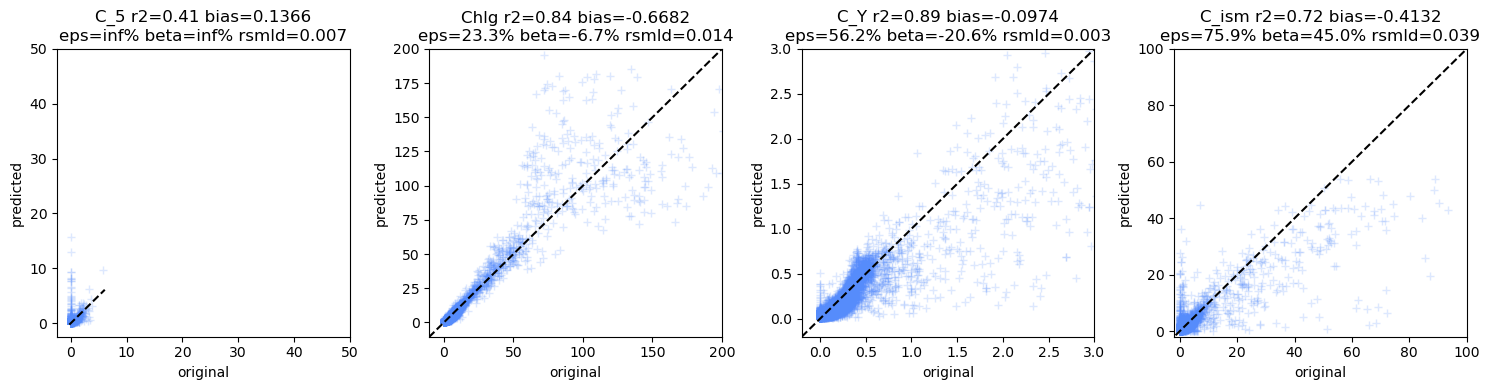

C5 25
['WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


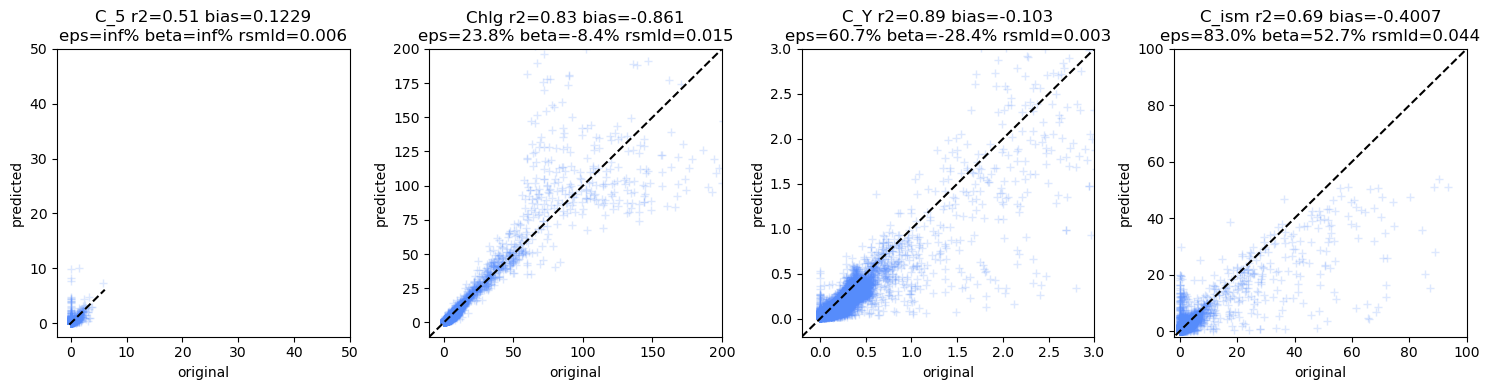

C5 30
['WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR']


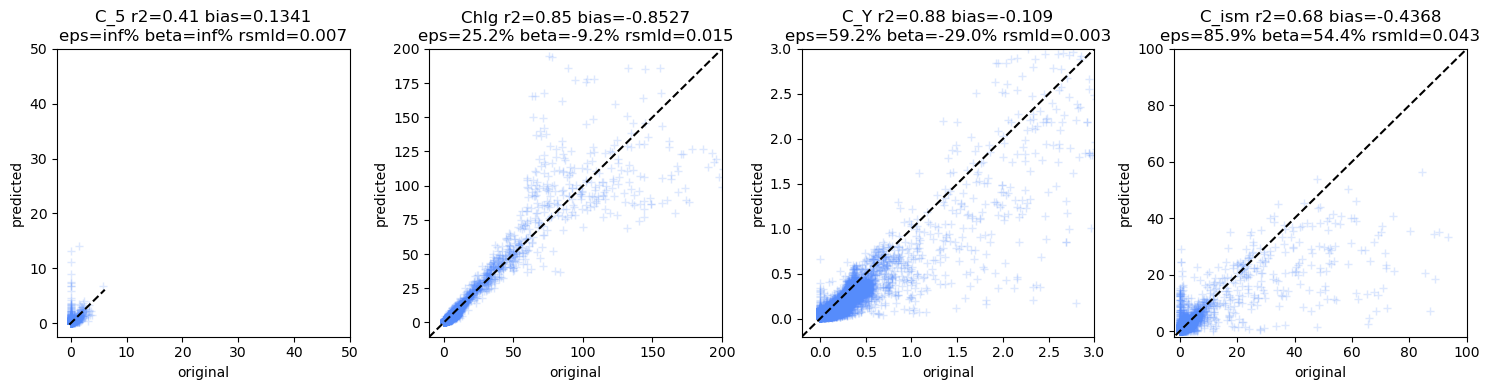

C5 40
['P' 'P' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


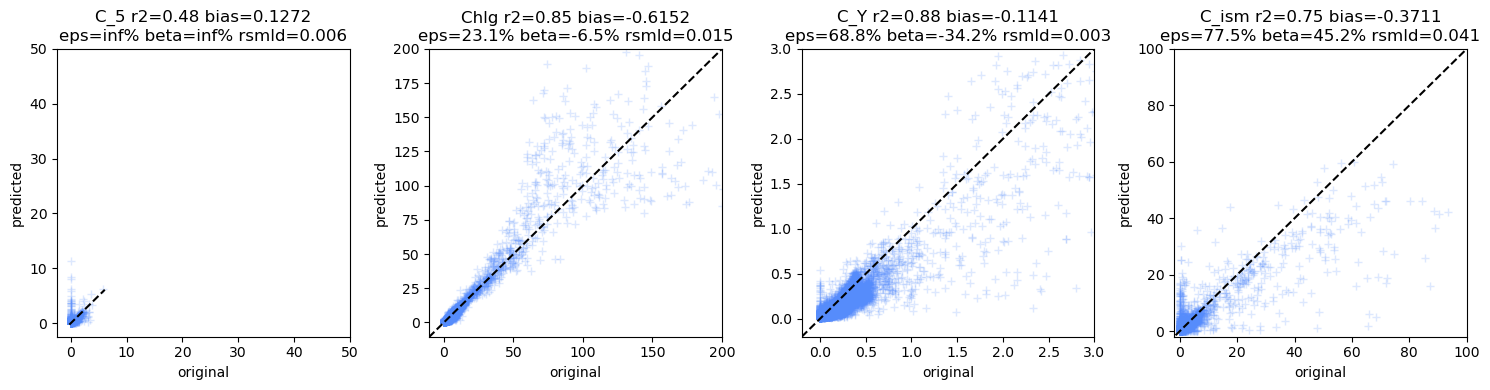

C5 50
['P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


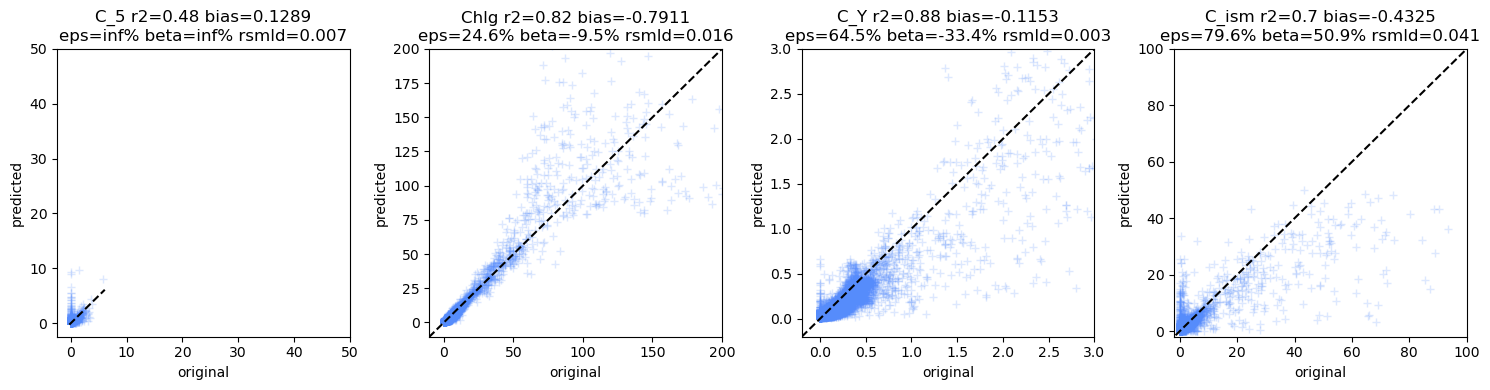

C5 123
['P' 'P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL'
 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_BandRatio[br] = sim_val[b1].values / sim_val[b2].values
C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_BandRatio[br] = sim_val[b1].values / sim_val[b2].values
C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many tim

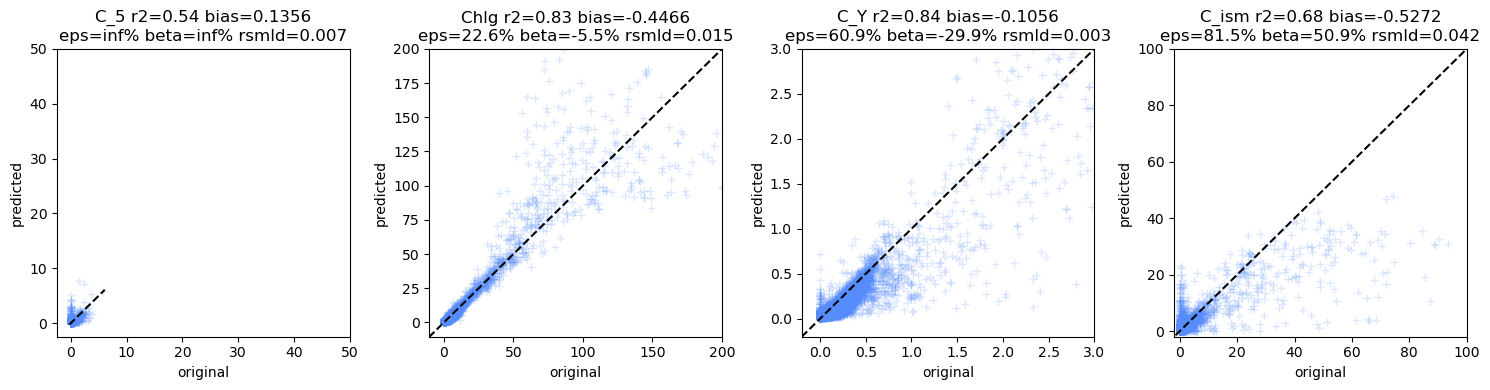

C6 10
['BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


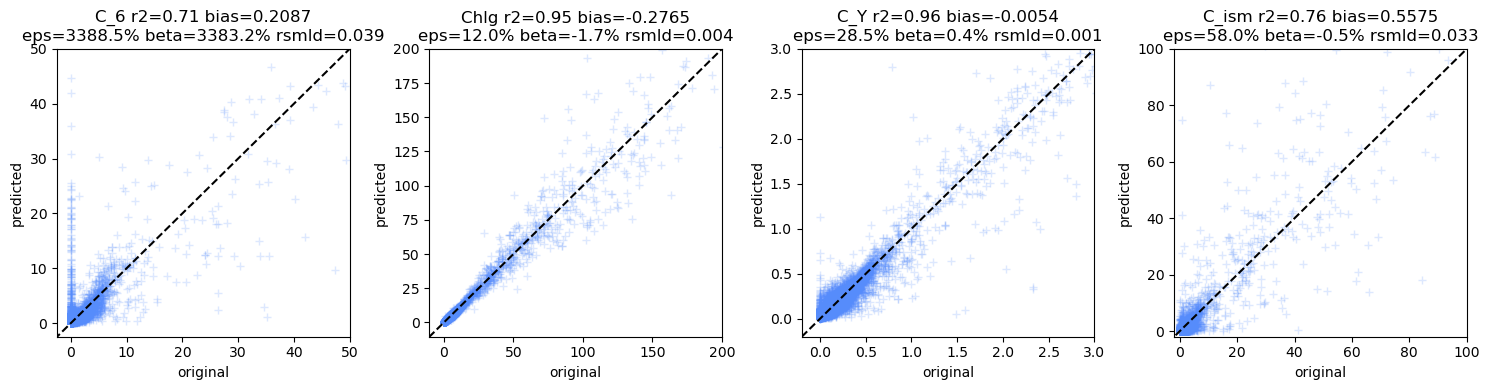

C6 15
['BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR']


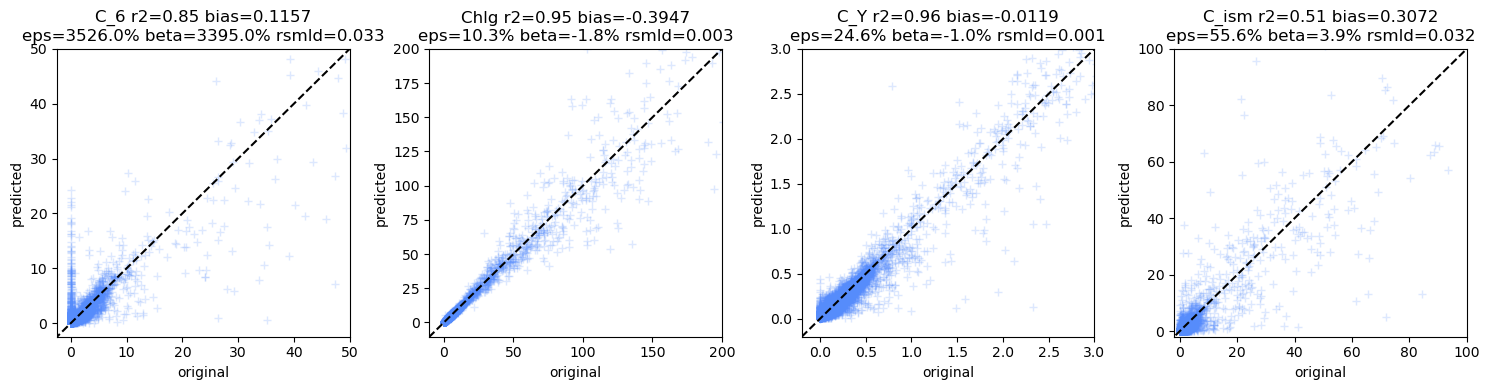

C6 20
['WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


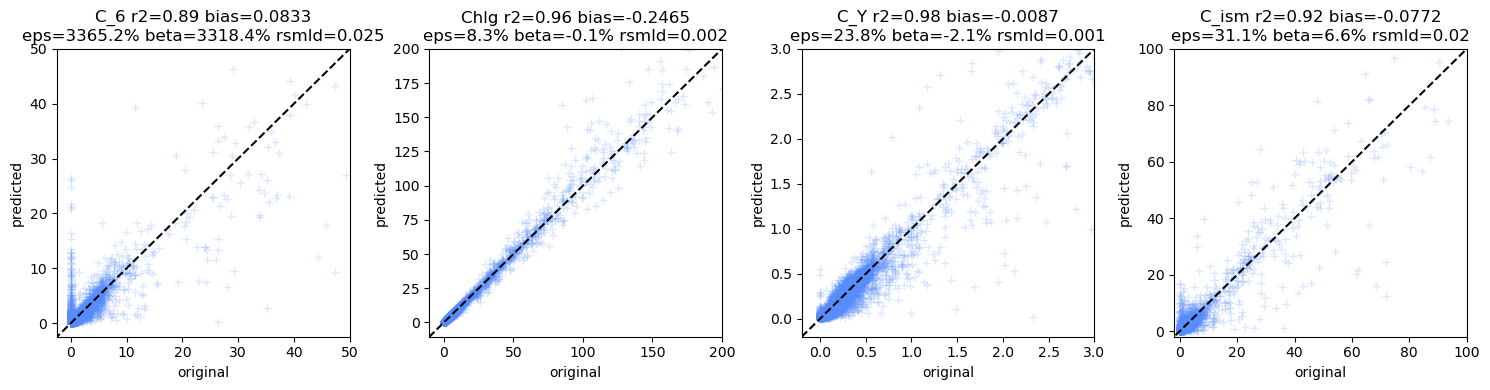

C6 25
['WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


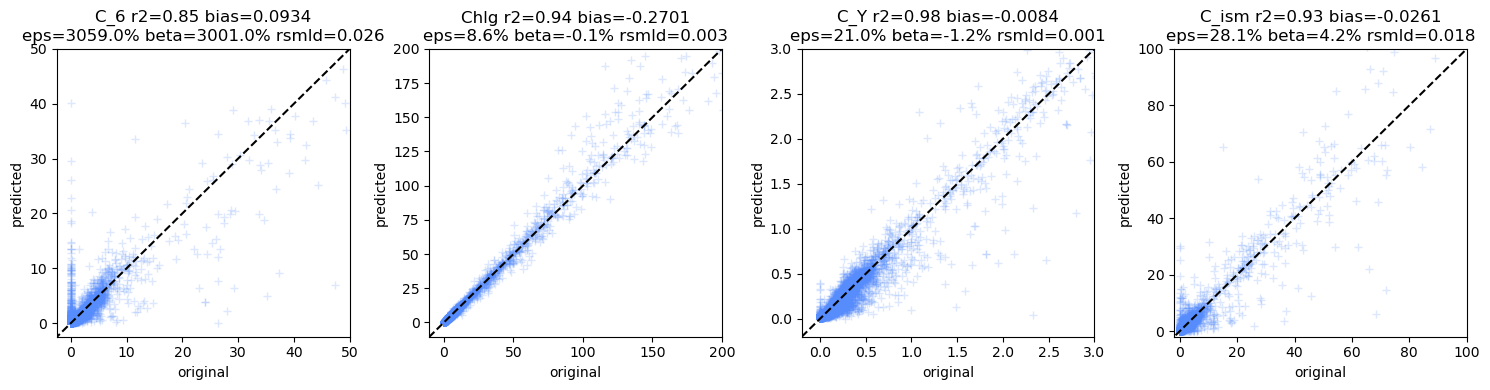

C6 30
['WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR']


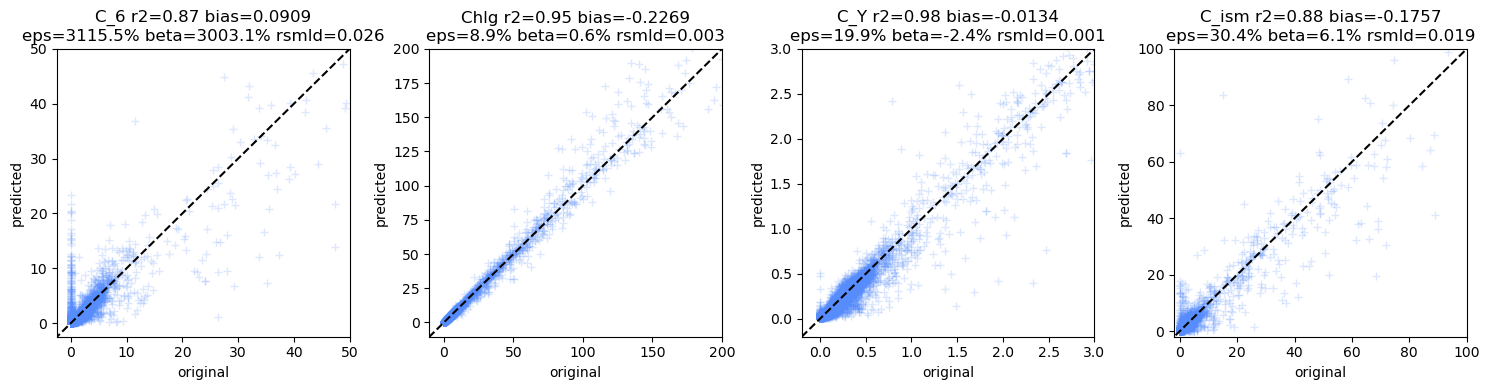

C6 40
['P' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


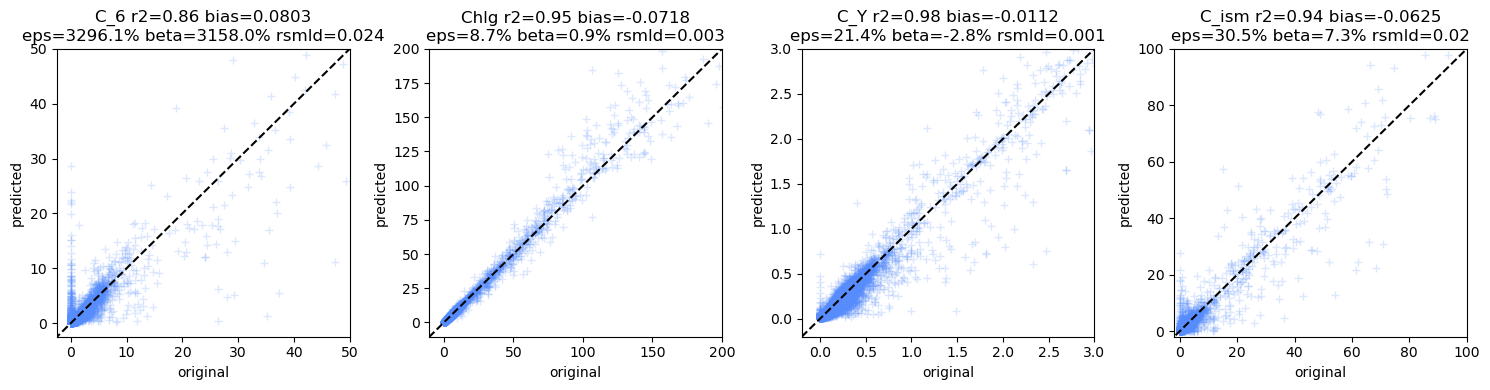

C6 50
['P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


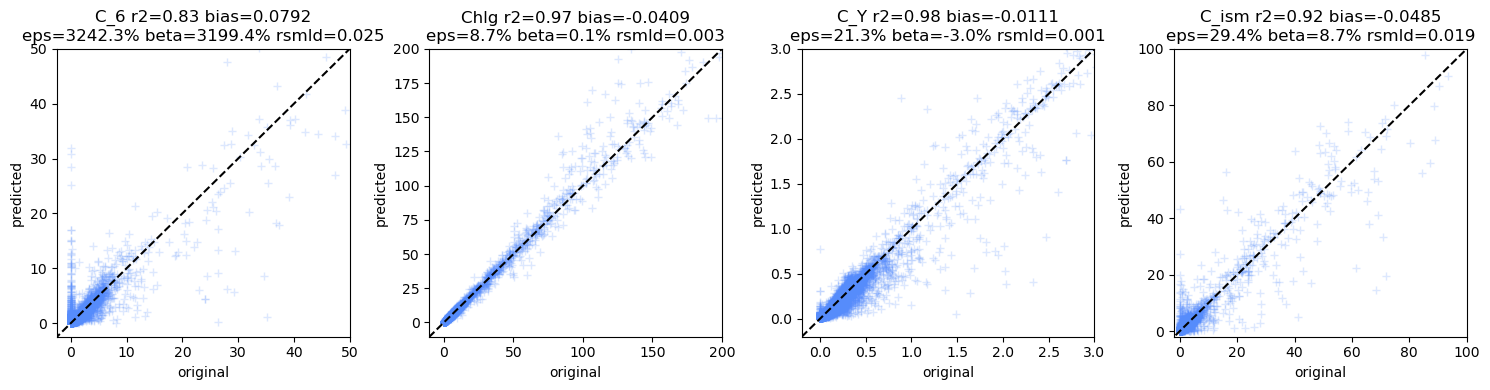

C6 193
['P' 'P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL'
 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_BandRatio[br] = sim_val[b1].values / sim_val[b2].values
C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  input_BandRatio[br] = sim_val[b1].values / sim_val[b2].values
C:\Users\Dagmar\AppData\Local\Temp\ipykernel_9172\1942527356.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many tim

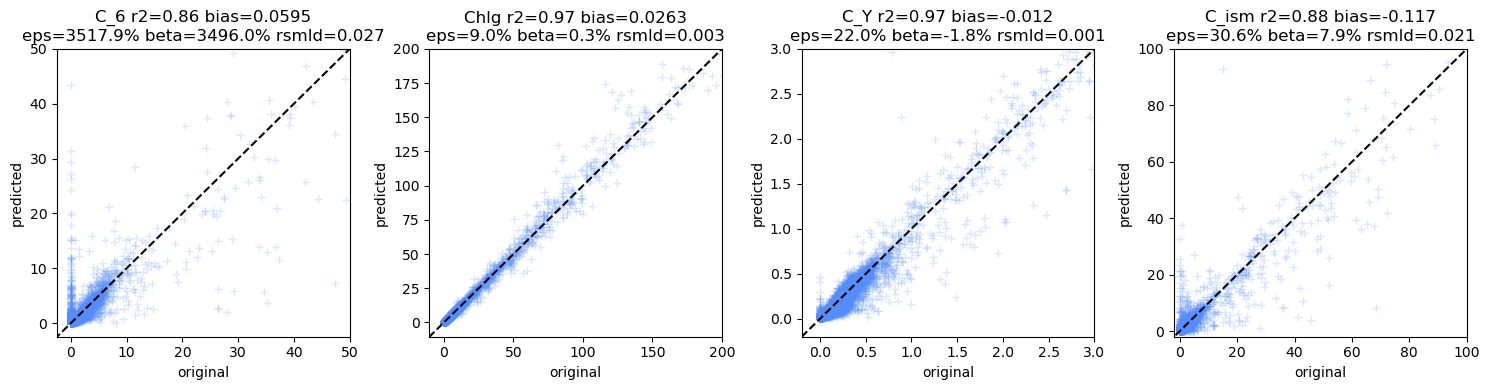

C7 10
['P' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


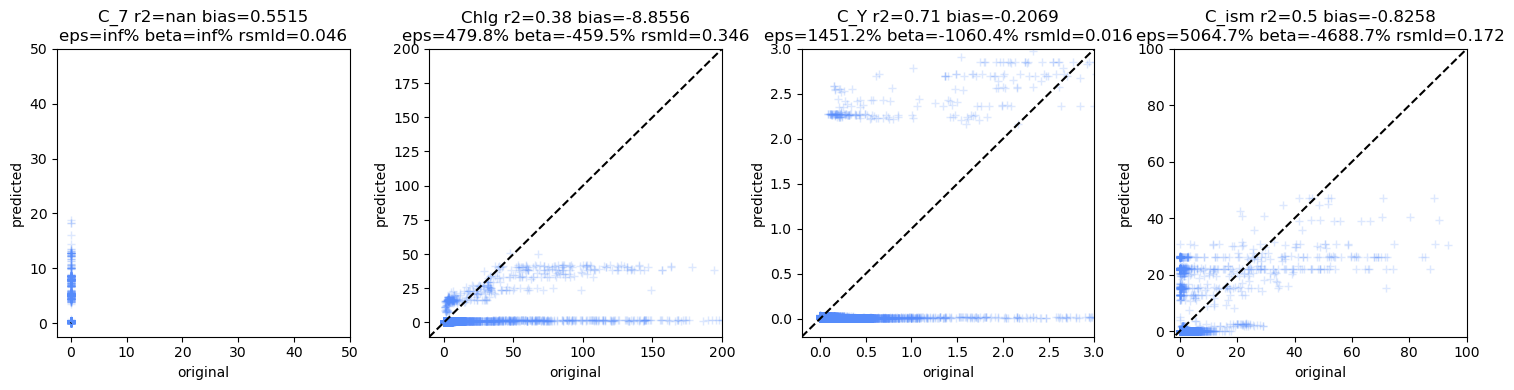

C7 15
['P' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


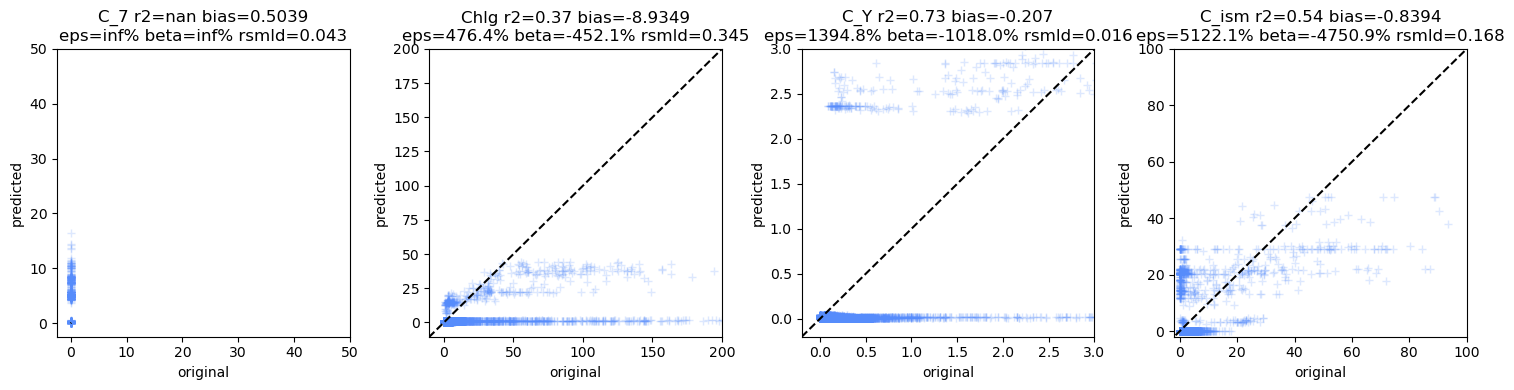

C7 20
['P' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


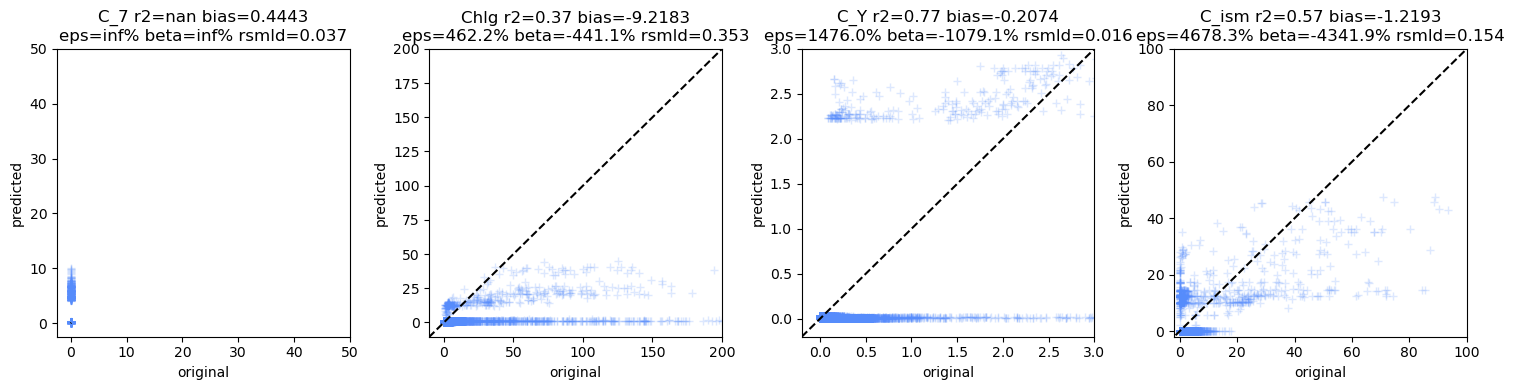

C7 25
['P' 'P' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


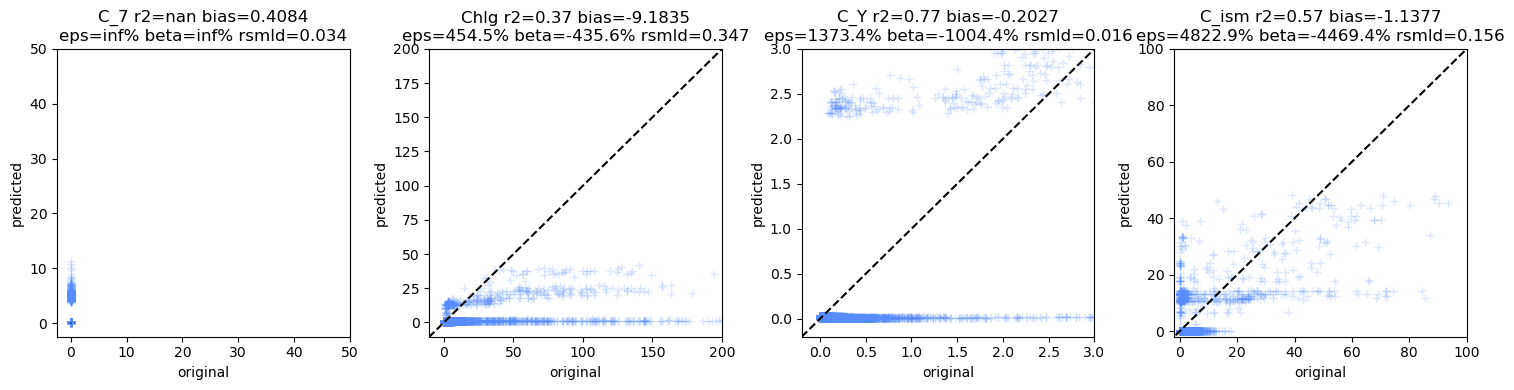

C7 30
['P' 'P' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


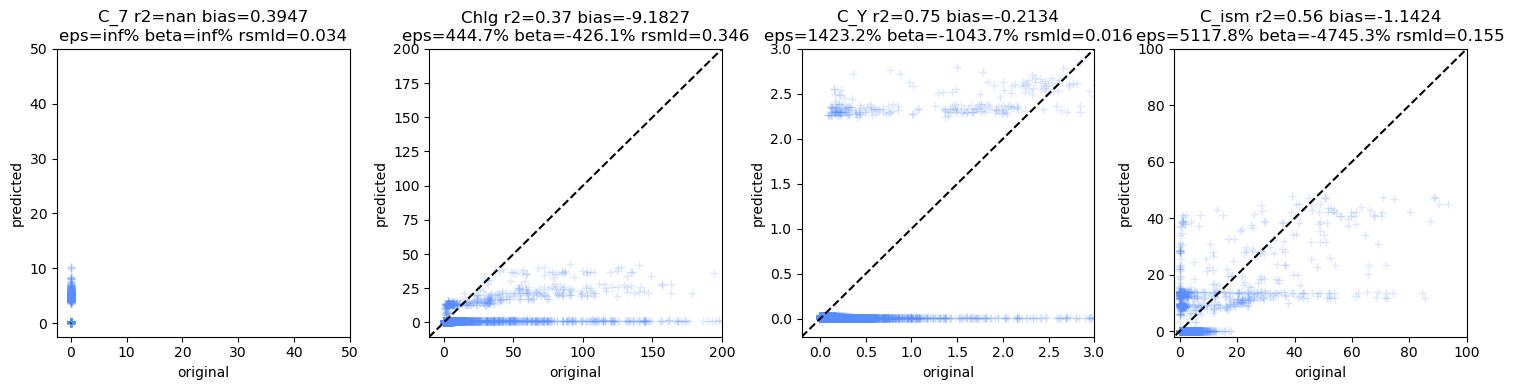

C7 40
['P' 'P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


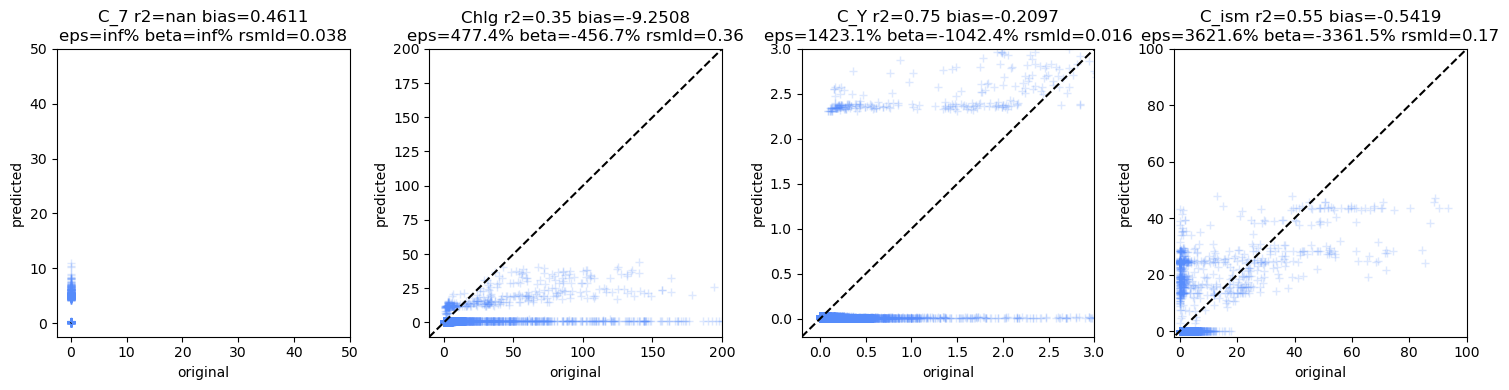

C7 50
['P' 'P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


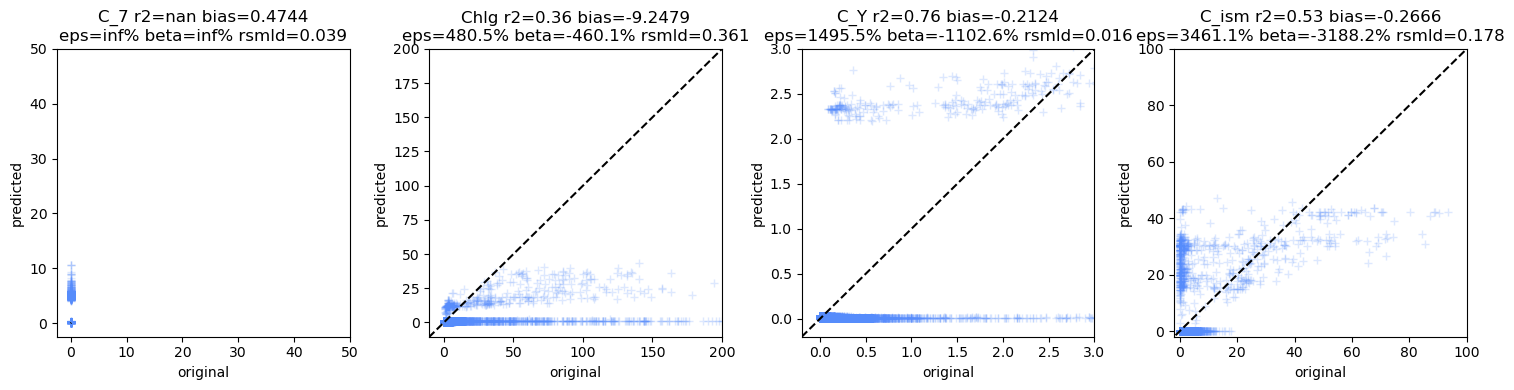

C7 69
['P' 'P' 'P' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'WL' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR'
 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR' 'BR']


F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
F:\Anaconda_envs\py_bio_optics_dev\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


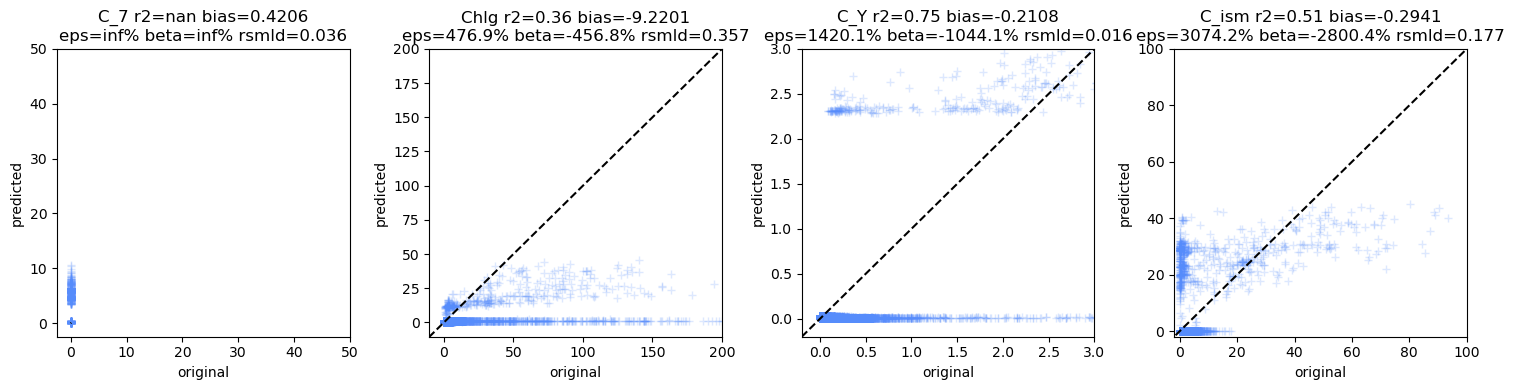

In [306]:
phytoList = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C5S', 'C7S']

## Mueggelsee
# insituDict = { 'C0': ['Ckie [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C1': ['Cgr [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C2': ['Ccry [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C3': ['Cbl [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C4': ['Cbl2 [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C5': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # coccoliths: not available in insitu!
#                'C6': ['Cdino [µg/l]', 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'],
#                'C7': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # case-1
#                'C5S': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # Phaeocystis
#                'C7S': [ None, 'Chlg [µg/l]', 'ag(440) [1/m]', 'NAP [mg/l]'], # Noctiluca
#                }

## files hold the names of features for the saved models
featureList = os.listdir(errorpath)
featureList = [fn for fn in featureList if fn.startswith('feature') and fn.endswith('.txt')]

outpath = "D:\Documents\projects\EnsAD\XGB_Training\\xgboost_CombSimul_TuningC_20250610_v03\\analysis\\"


for phyto in phytoList[5:8]:
    outStatDF = pd.DataFrame()
    inputDictAll = set_inputDict_byPhytoGroup(phyto)

    for modelNparam in inputDictAll.keys():
        print(phyto, modelNparam)
        inputDict = { phyto : inputDictAll[modelNparam]}
        inputDictOrdered = setup_InputXGBmodel_ordered(inputDict, wavelengthDict)

        ## BandRatio DF
        # ## Simulations Rrs Bandratios
        input_BandRatio = pd.DataFrame()
        print(inputDictOrdered[phyto]['type'])
        IDbandratio = inputDictOrdered[phyto]['cols'][inputDictOrdered[phyto]['type']=='BR']
        for br in IDbandratio:
            b1, b2 = br.split('/')
            # input_BandRatio[br] = Rrs1nmDF[b1].values / Rrs1nmDF[b2].values
            input_BandRatio[br] = sim_val[b1].values / sim_val[b2].values


        inputDict_Model = {
            'parameter': {'data': inputDF_val,
                     'col': inputDictOrdered[phyto]['cols'][inputDictOrdered[phyto]['type']=='P'],
                     'threshold': None,
                     'logTrans_col': None},
            'bands': {'data': sim_val,
                     'col': inputDictOrdered[phyto]['cols'][inputDictOrdered[phyto]['type']=='WL'],
                     'threshold': None,
                     'logTrans_col': None},
            'BandRatio': {'data': input_BandRatio,
                         'col': input_BandRatio.columns.values,
                         'threshold': None,
                         'logTrans_col': None}
        }

        thisInput, thisOutput =  setup_training_data_selection_generic(inputDict= inputDict_Model, outputDict=None, ID=None)

        ## select model
        xgb_model_path = "D:\Documents\projects\EnsAD\XGB_Training\\xgboost_CombSimul_TuningC_20250610_v03\\invNNoneC_specifWL\\"

        ## select the correct model based on the number of inputs and the phytoplankton group
        modelFnames = os.listdir(xgb_model_path)
        # ../model_InversionXGB_Sim2Conc_I10_O4log_LakesC1
        if phyto.endswith('S'):
            modelFnames = [mf for mf in modelFnames if 'I'+str(modelNparam)+'_' in mf and 'SummerLakes'+phyto[:-1] in mf]
        else:
            modelFnames = [mf for mf in modelFnames if 'I'+str(modelNparam)+'_' in mf and 'Lakes'+phyto in mf]

        ## setup model & Predict
        n = 2000
        model_inv = xgb.XGBRegressor(objective="reg:squarederror", eval_metric=['rmse'], early_stopping_rounds=3,
                                     n_estimators=n, learning_rate=0.2)  # n=20000

        model_inv.load_model(xgb_model_path+modelFnames[0])
        CX_predict = model_inv.predict(thisInput.values)

        ## Calculate errors on log10 values!
        # insituLog = iop_insitu[insituVarL[1:]].copy()
        # for a in insituLog.columns.values:
        #     insituLog[a] = np.log10(insituLog[a])
        insituVarL = [phyto[0]+'_'+phyto[1:], 'Chlg', 'C_Y', 'C_ism']
        insituLog = iop_val[insituVarL].copy()
        # for a in insituLog.columns.values:
        #     insituLog[a] = np.log10(insituLog[a])

        statDF = plot_validation_results(insituLog, 10**CX_predict[:,:], output_label=insituVarL[:],
                                         thisLim = np.array((-2.5, 50)),
                                    logStat = [True],  # either single boolean for all output_label, or list of boolean for each output_label
                                    minVDict = { 'Chlg': -10.5, 'C_Y': -.2, 'C_ism': -2.0},
                                    maxVDict = { 'Chlg': 200, 'C_Y': 3., 'C_ism': 100.},
                                    # thisLim = np.array((-2.5, 2.5)),
                                    # logStat = [True],  # either single boolean for all output_label, or list of boolean for each output_label
                                    # minVDict = { 'Chlg': -1.5, 'C_Y': -2., 'C_ism': -3.0},
                                    # maxVDict = { 'Chlg': 2.2, 'C_Y': 0., 'C_ism': 1.},
                                         stat_output=True, logNorm=False)
        statDF['NpredV'] = modelNparam
        if len(outStatDF) == 0:
            outStatDF = statDF.copy()
        else:
            outStatDF = pd.concat([outStatDF, statDF], axis=0)


    outStatDF.to_csv(outpath+ "stat_"+phyto+"_allModels_"+typeD+"_EnMAP2Model_"+date+".txt", header=True, index=False, sep='\t')

# ToDO: Errors from optical closure?
Not easy, as only a single component and total chl, cdom, NAP are retrieved.
How can we forward model a spectrum from that information, which is representative enough?
It should allow to check that

# Inversion Development CHIME
- From specific absorption spectra: collect all relevant bands.
- Select those closest to CHIME bands!
- Training on Bi&Hi Simulations (EnMAP, PACE)!!
- Validation on Bi&Hi Simulations from insitu Concentrations (HEATWISE, AQUATIME)
- Minimisation: Optical closure (SAM, rMAE) and concentrations (phyto groups, CDOM, TSS)
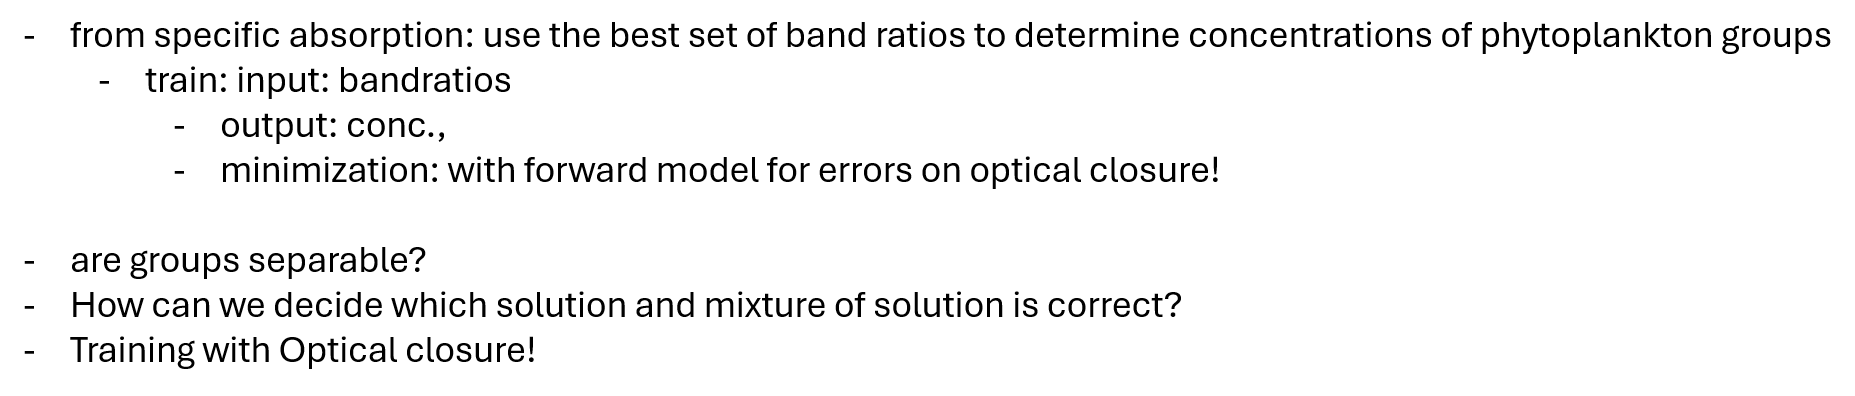

## Read validation data

In [1]:
metaDict = {'muggelsee': { 'project': 'HEATWISE',
        'path' : "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\\representative_dataset\\berlin_muggelsee\\",
        'iop_path': "Z:\projects\ongoing\HEATWISE\sharepoint\WP2_workspace\Water Quality\Muggelsee - Berlin\input_simulations\\",
        'datasetNameIOP': "berlin_muggelsee_IOP_daily_v0.3.", #"berlin_muggelsee_IOP_daily_v0.3_SZA_Gx_OZA2"
        'lat': 52.4373,
        'lon': 13.6474,
        'specNAP_variable': False,
        'PhytoGroupSet' : 'HEREONgold',
        'versionNumber': 'v2.0'  # something is wrong with version v0.3.0!
        }}

In [4]:
## BC Bi&Hieronymi forward simulations
## these can have CHIME wavelengths!!
regionName = 'muggelsee'
projectName =metaDict[regionName]['project']

if projectName == 'HEATWISE':
    fwpath = "Z:\projects\\ongoing\HEATWISE\\sharepoint\WP2_workspace\Water Quality\FullInversion\\bio-optics_forward\\"
elif projectName == 'AQUATIME':
    fwpath ="Z:\projects\\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\RTM_simulations\FullInversion\\bio-optics_forward\\"
iop_path = metaDict[regionName]['iop_path']

fnames = os.listdir(fwpath)
# fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName.split('_')[0] in fn and regionName.split('_')[1] in fn]
fnames = [fn for fn in fnames if fn.startswith('SimRrs') and regionName in fn and 'CHIME' in fn] # CHIME bands!
print(fnames)
# # fname = "SimRrs_InsituForward_HEREONorig_HEREONgoldinverted_IOP_bio_optics_HEREONfull_CHIME_sim_AQUATIME_pyhajarvi_allOWTs_Inv0_Inv0.1.txt" # naming ??
forward = pd.read_csv(fwpath+fnames[0], sep='\t', header=0)

# iop_path = 'Z:\projects\ongoing\AQUATIME\sharepoint\WP2 Representative Dataset\\RTM_simulations\IOPs\Case Study 3 Vörtsjärv\\'
datasetNameIOP = metaDict[regionName]['datasetNameIOP']
fname = os.listdir(iop_path)
fname = [fn for fn in fname if fn.startswith(datasetNameIOP) and 'v0.3' in fn]  # Helsinki: 'IOP' in fn and ... 'v0.1b'
print(fname[0])
iop_insitu = pd.read_csv(iop_path+ fname[0], sep=',')
iop_insitu['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
iop_insitu = iop_insitu.set_index('date')

forward['date'] = pd.to_datetime([str(a).split('+')[0] for a in iop_insitu['datetime'].values])
forward = forward.set_index('date')
wl_fw = np.asarray([float(a) for a in forward.columns.values])

print('forward', forward.shape)
print('insitu', iop_insitu.shape)

['SimRrs_InsituForward_HEREONgold_berlin_muggelsee_IOP_daily_CHIMEbands.txt']
berlin_muggelsee_IOP_daily_v0.3.csv
forward (3074, 71)
insitu (3074, 35)


In [6]:
varList = ['Chlg [µg/l]', 'Cgr [µg/l]', 'Ckie [µg/l]', 'Cbl [µg/l]', 'Cbl2 [µg/l]', 'Ccry [µg/l]', 'Cgold [µg/l]', 'Cdino [µg/l]']
for v in varList:
    print(v, np.nanpercentile(iop_insitu[v], [5, 50, 95]))

Chlg [µg/l] [ 1.07457313  8.79743725 41.29782509]
Cgr [µg/l] [0.00539381 0.10862864 2.11543682]
Ckie [µg/l] [ 0.24037666  3.4236977  26.70468656]
Cbl [µg/l] [9.86809005e-04 4.51000707e-02 1.32741893e+01]
Cbl2 [µg/l] [0. 0. 0.]
Ccry [µg/l] [0.21711517 1.56046294 8.76448499]
Cgold [µg/l] [0.00756486 0.13202237 2.2807578 ]
Cdino [µg/l] [1.30206943e-03 4.55498154e-03 1.49485776e+00]


## Important wavelengths
| Phytoplankton Gruppe | 	Spezifische Absorption, relative Maxima. Wellenlänge [nm] | 	Spezifische Absorption, relative Minima. Wellenlänge [nm] |
|----------------------|------------------------------------------------------------|------------------------------------------------------------|
| C_0 Brown            | 	413, 438, 466, 496, 636, 674                              | 425, 450, 480, 566, 604, 651, 718                          |
| C_1 Green            | 414, 438, 478, 650, 675                                    | 460, 550, 638, 658, 718                                    |
| C_2 Cryptophyceae| 	414, 437, 468, 497, 548, 632, 676                         | 426, 453, 482, 522, 604,650, 718                           |
| C_3 Cyano blue| 	416, 436, 496, 627, 677                                   | 426, 456, 482, 532, 550, 602, 654, 718                     |
| C_4 Cyano red| 	414, 437, 497, 542, 565, 630, 677                         | 426, 456, 478, 522, 600, 610, 650, 718                     |
| C_5 Coccolith.| 	414, 440, 464, 494, 591, 637, 676                         | 426, 452, 570, 606, 620, 652, 660, 718                     |
| C_6 Dinoflagellates (LOMAS)| 	412, 438, 468, 496, 538, 570, 592, 620, 633, 676          | 424, 436, 450, 484, 512, 569, 604, 652, 718                |
| C_7 case-1| 	419, 442, 490, 628, 673                                   | 432, 476, 530, 560, 648, 658, 720                          |
| C_5* Phaeocystis| 	414, 440, 470, 538, 591, 638, 675                         | 426, 452, 514, 570, 606, 652, 718                          |
| C_7* Noctiluca| 410, 464, 485, 520, 626, 672                               | 444, 510, 528, 568, 652, 718                               |


In [7]:
wlDict = {
    'C_0 Brown': { 'Max': (413, 438, 466, 496, 636, 674), 'Min': (425, 450, 480, 566, 604, 651, 718)},
    'C_1 Green': { 'Max': (414, 438, 478, 650, 675), 'Min': (460, 550, 638, 658, 718)},
    'C_2 Cryptophyceae': { 'Max': (414, 437, 468, 497, 548, 632, 676), 'Min': (426, 453, 482, 522, 604,650, 718)},
    'C_3 Cyano blue': { 'Max': (416, 436, 496, 627, 677), 'Min': (426, 456, 482, 532, 550, 602, 654, 718)},
    'C_4 Cyano red': { 'Max': (414, 437, 497, 542, 565, 630, 677), 'Min': (426, 456, 478, 522, 600, 610, 650, 718)},
    'C_5 Coccolith.': { 'Max': (414, 440, 464, 494, 591, 637, 676), 'Min': (426, 452, 570, 606, 620, 652, 660, 718)},
    'C_6 Dinoflagellates (LOMAS)': { 'Max': (412, 438, 468, 496, 538, 570, 592, 620, 633, 676), 'Min': (424, 436, 450, 484, 512, 569, 604, 652, 718)},
    'C_7 case-1': { 'Max': (419, 442, 490, 628, 673), 'Min': (432, 476, 530, 560, 648, 658, 720)},
    'C_5* Phaeocystis': { 'Max': (414, 440, 470, 538, 591, 638, 675), 'Min': (426, 452, 514, 570, 606, 652, 718)},
    'C_7* Noctiluca': { 'Max': (410, 464, 485, 520, 626, 672), 'Min': (444, 510, 528, 568, 652, 718)},
    'C_5** Goldalgae': {'Max', 'Min'}
}

In [29]:
wlDict.keys()

dict_keys(['C_0 Brown', 'C_1 Green', 'C_2 Cryptophyceae', 'C_3 Cyano blue', 'C_4 Cyano red', 'C_5 Coccolith.', 'C_6 Dinoflagellates (LOMAS)', 'C_7 case-1', 'C_5* Phaeocystis', 'C_7* Noctiluca'])

In [23]:
deltaWL = 5.
GroupList = ['C_0 Brown', 'C_1 Green', 'C_2 Cryptophyceae', 'C_3 Cyano blue', 'C_6 Dinoflagellates (LOMAS)', 'C_7 case-1', 'C_5* Phaeocystis', 'C_7* Noctiluca']
wlDict2 = {}
for k in wlDict.keys():
    maxV = []
    for v in wlDict[k]['Max']:
        ID = np.abs(wl_fw - v) == np.min(np.abs(wl_fw - v))
        if np.sum(ID)> 1:
            y = wl_fw[ID]
            [maxV.append(a) for a in y]
        else:
            maxV.append(wl_fw[ID][0])
    minV = []
    for v in wlDict[k]['Min']:
        ID = np.abs(wl_fw - v) == np.min(np.abs(wl_fw - v))
        if np.sum(ID)> 1:
            y = wl_fw[ID]
            [minV.append(a) for a in y]
        else:
            minV.append(wl_fw[ID][0])

    wlDict2[k] = {'Max': np.asarray(maxV), 'Min': np.asarray(minV)}


In [25]:
allMin = []
allMax = []
for k in wlDict2.keys():
    [allMin.append(a) for a in wlDict2[k]['Min']]
    [allMax.append(a) for a in wlDict2[k]['Max']]

allMin = np.unique(np.asarray(allMin))
allMax = np.unique(np.asarray(allMax))

In [26]:
allMin

array([421. , 429.4, 437.8, 446.2, 454.6, 463. , 479.8, 488.2, 513.4,
       521.8, 530.2, 547. , 563.8, 572.2, 597.4, 605.8, 614.2, 622.6,
       639.4, 647.8, 656.2, 715. , 723.4])

In [27]:
allMax

array([412.6, 421. , 437.8, 446.2, 463. , 471.4, 479.8, 488.2, 496.6,
       521.8, 538.6, 547. , 563.8, 572.2, 589. , 622.6, 631. , 639.4,
       647.8, 673. ])

In [28]:
print(len(allMin), len(allMax))

23 20
